# Bias Analysis - Study1

## Loading Libraries & Data

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib as mpl
import requests
from pathlib import Path
import json
import re
import yfinance as yf
import math
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import itertools
from scipy import stats
import string

In [2]:
ageRisk = pd.read_csv('./processed/ageRisk_long.csv', index_col=0)

## Resolving ETFs 

In [3]:
# Calculates the weight of a position in a portfolio 
def get_position_weight(portfolio_df):
    position_weight = portfolio_df / portfolio_df.sum()
    return position_weight

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'iteration', 'ticker_symbol', 'amount_to_invest', 'weight', 'sector', 'asset_type', 'country']
ageRisk['weight'] = ageRisk.groupby(['ai', 'age', 'risk-taking', 'iteration'])['amount_to_invest'].transform(get_position_weight)
ageRisk = ageRisk[ageRisk_select_cols]

ageRisk_unique_etfs = ageRisk[ageRisk["asset_type"] == "ETF"]["ticker_symbol"].unique()
etfs = ageRisk_unique_etfs

ageRisk_unique_funds = ageRisk[ageRisk["asset_type"] == "MUTUALFUND"]["ticker_symbol"].unique()
funds = ageRisk_unique_funds

In [4]:
etfs

array(['AGG', 'BND', 'VYM', 'VOO', 'GOVT', 'VNQ', 'EEM', 'SPY', 'IEF',
       'VTI', 'ICLN', 'QQQ', 'ARKK', 'HYG', 'NOBL', 'XLK', 'TLT', 'LQD',
       'VXUS', 'VGT', 'XLV', 'XLY', 'IEMG', 'TAN', 'GLD', 'VIG', 'DBC',
       'VEU', 'ARKW', 'SSO', 'SLV', 'GBTC', 'IVV', 'SHY', 'AOK', 'VCSH',
       'TIP', 'SCHH', 'IEFA', 'VUG', 'IWM', 'VB', 'VBK', 'VWO', 'VBR',
       'ARKG', 'BOTZ', 'ANGL'], dtype=object)

In [5]:
funds

array(['VBMFX', 'SWPPX', 'VTSAX', 'VBTLX', 'VTSMX', 'VGSLX', 'FCNTX',
       'VIGAX', 'VFIAX', 'VFINX', 'VTMGX', 'FTBFX', 'FZROX', 'VDIGX', nan,
       'VSCGX', 'VTINX', 'PRGTX', 'PRGFX', 'VBINX', 'VSMGX', 'VBIAX',
       'FSKAX', 'VFSAX', 'VTWAX', 'VTBIX', 'VTTSX', 'VFIFX', 'VTWNX',
       'VFIUX', 'VFIJX'], dtype=object)

In [6]:
resStr_etf = ""
os = ['QQQ', 'SHY', 'VXUS', 'ICLN', 'BND', 'BOTZ', 'IEF', 'TLT', 'SOXX', 'ANGL', 'VCSH', 'REIT']
ks = ['GOVT', 'IEFA', 'ARKK', 'ARKW', 'ARKG', 'NOBL', 'IEMG', 'SCHH']
for etf in etfs:
    if etf in os:
        resStr_etf += f'{etf}.O;'
    elif etf in ks:
        resStr_etf += f'{etf}.K;'
    else:
        resStr_etf += f'{etf};'
resStr_etf

'AGG;BND.O;VYM;VOO;GOVT.K;VNQ;EEM;SPY;IEF.O;VTI;ICLN.O;QQQ.O;ARKK.K;HYG;NOBL.K;XLK;TLT.O;LQD;VXUS.O;VGT;XLV;XLY;IEMG.K;TAN;GLD;VIG;DBC;VEU;ARKW.K;SSO;SLV;GBTC;IVV;SHY.O;AOK;VCSH.O;TIP;SCHH.K;IEFA.K;VUG;IWM;VB;VBK;VWO;VBR;ARKG.K;BOTZ.O;ANGL.O;'

In [7]:
resStr_mutualFunds = "";
for fund in funds:
    resStr_mutualFunds += f'{fund}.O;'
resStr_mutualFunds

'VBMFX.O;SWPPX.O;VTSAX.O;VBTLX.O;VTSMX.O;VGSLX.O;FCNTX.O;VIGAX.O;VFIAX.O;VFINX.O;VTMGX.O;FTBFX.O;FZROX.O;VDIGX.O;nan.O;VSCGX.O;VTINX.O;PRGTX.O;PRGFX.O;VBINX.O;VSMGX.O;VBIAX.O;FSKAX.O;VFSAX.O;VTWAX.O;VTBIX.O;VTTSX.O;VFIFX.O;VTWNX.O;VFIUX.O;VFIJX.O;'

In [8]:
resStr_funds = resStr_etf + resStr_mutualFunds
resStr_funds

'AGG;BND.O;VYM;VOO;GOVT.K;VNQ;EEM;SPY;IEF.O;VTI;ICLN.O;QQQ.O;ARKK.K;HYG;NOBL.K;XLK;TLT.O;LQD;VXUS.O;VGT;XLV;XLY;IEMG.K;TAN;GLD;VIG;DBC;VEU;ARKW.K;SSO;SLV;GBTC;IVV;SHY.O;AOK;VCSH.O;TIP;SCHH.K;IEFA.K;VUG;IWM;VB;VBK;VWO;VBR;ARKG.K;BOTZ.O;ANGL.O;VBMFX.O;SWPPX.O;VTSAX.O;VBTLX.O;VTSMX.O;VGSLX.O;FCNTX.O;VIGAX.O;VFIAX.O;VFINX.O;VTMGX.O;FTBFX.O;FZROX.O;VDIGX.O;nan.O;VSCGX.O;VTINX.O;PRGTX.O;PRGFX.O;VBINX.O;VSMGX.O;VBIAX.O;FSKAX.O;VFSAX.O;VTWAX.O;VTBIX.O;VTTSX.O;VFIFX.O;VTWNX.O;VFIUX.O;VFIJX.O;'

In [9]:
# BSCM ended on 15.12.2022, GLD, SLV, DbC

## Loading Data from Refinitiv & Resolving Dataset

In [10]:
# Transforms and cleans a given Refinitiv data set to be usable
def prepare_refinitiv_dataset(df, columns):
    df = df.iloc[1:].reset_index()
    df.columns = columns
    df['economic_sector'] = df['economic_sector'].replace('Unable to resolve all requested identifiers.', np.nan)
    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['economic_sector'].str.startswith('Unable to')
    df.loc[condition & ~df['economic_sector'].isna(), 'country'] = np.nan
    df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
    df['weight'] = df['weight'].fillna(100.0)
    df['weight'] = df['weight'] / 100
    df['fund'] = df['fund'].str.split('.').str[0]
    return df

# Returns the current asset ticker of a row
def create_ticker(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['symbol']
    else:
        return row['ticker_symbol']
        
# Returns the current asset ticker of a row on the second resolving iteration
def create_ticker_l2(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['ticker'] if pd.isnull(row['equity_l2']) else row['symbol_l2']
    else:
        return row['ticker']

# Harmonizes Yahoo Finance and Refinitiv sector names
def harmonize_sectors(sector):
    if sector == 'Consumer Cyclicals':
        return 'Consumer Cyclical'
    elif sector == 'Financial Services':
        return 'Financials'
    elif sector == 'Consumer Defensive':
        return 'Consumer Non-Cyclicals'
    else:
        return sector

# Resolves funds into equities (second resolving iteration)
def resolve_layer2(df, select_cols):
    df = df.merge(additional_data, left_on='ticker', right_on='fund', how='left', suffixes=('_l1','_l2'))
    df['weight_l2'].fillna(1, inplace=True)
    df['weight'] = df['weight_l1'] * df['weight_l2']
    df['sector'] = df['sector'].fillna(df['economic_sector_l2'])
    df['country'] = df.apply(
        lambda row: row['country_l2'] if pd.isnull(row['country_l1']) else row['country_l1'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker_l2(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount'] * row['weight_l2'], axis=1)

    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['sector'].str.startswith('Unable to')
    df.loc[condition & ~df['sector'].isna(), 'sector'] = np.nan

    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    df['country'] = df['country'].fillna('UNKNOWN')
    df['ticker'] = df['ticker'].fillna('UNKNOWN')
    #df = df[select_cols]
    return df

# Resolves funds into equities (first resolving iteration)
def prepare_data(df, select_cols):
    df = df.merge(fund_data, left_on='ticker_symbol', right_on='fund', how='left')
    df['weight_y'].fillna(1, inplace=True)
    df['weight'] = df['weight_x'] * df['weight_y']
    df['sector'] = df['sector'].fillna(df['economic_sector'])
    df['sector'] = df.apply(
        lambda row: 'Crypto' if row['asset_type'] == 'CRYPTOCURRENCY' else row['sector'],
        axis=1
    )
    df['country_x'] = df['country_x'].str.upper()
    df['country'] = df.apply(
        lambda row: row['country_y'] if pd.isnull(row['country_x']) else row['country_x'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount_to_invest'] * row['weight_y'], axis=1)
    df['sector'] = df['sector'].apply(harmonize_sectors) 
    return resolve_layer2(df, select_cols)

# Prepares the benchmark for comparison
def prepare_benchmark(df):
    df = df.rename(columns={'economic_sector': 'sector'})
    df['amount'] = df['weight'].apply(lambda x: x * 10000)
    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['country'] = df['country'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    return df
 
cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'type', 'economic_sector']
etf_data = pd.read_csv('./etf_holdings/refinitiv/etfs_refinitiv.csv', index_col=0)
etf_data = prepare_refinitiv_dataset(etf_data, cols_refinitiv)

mutualFund_data = pd.read_csv('./mutualFund_holdings/refinitiv/mutualFunds_refinitiv.csv', index_col=0)
mutualFund_data = mutualFund_data.iloc[:,:-2]
mutualFund_data = prepare_refinitiv_dataset(mutualFund_data, cols_refinitiv)

fund_data = pd.concat([etf_data, mutualFund_data], ignore_index=True)

additional_data = pd.read_csv('./etf_holdings/refinitiv/additions_refinitiv.csv', index_col=0)
additional_data = prepare_refinitiv_dataset(additional_data, cols_refinitiv)
additional_data = pd.concat([fund_data, additional_data], ignore_index=True)

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'iteration', 'asset_type', 'ticker', 'weight', 'country', 'sector', 'amount']
ageRisk_resolved = prepare_data(ageRisk, ageRisk_select_cols)

benchmark_cols_refinitiv = ['fund', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector', 'business_sector', 'industry_group']
benchmark = pd.read_csv('./benchmark/refinitiv/benchmarks_refinitiv.csv', index_col=0)
benchmark_prepared = prepare_benchmark(prepare_refinitiv_dataset(benchmark, benchmark_cols_refinitiv))

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_25248/13441933.py:96: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  etf_data = pd.read_csv('./etf_holdings/refinitiv/etfs_refinitiv.csv', index_col=0)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_25248/13441933.py:99: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  mutualFund_data = pd.read_csv('./mutualFund_holdings/refinitiv/mutualFunds_refinitiv.csv', index_col=0)


In [11]:
benchmark_ftse = benchmark_prepared[benchmark_prepared['fund'] == 'VFAWF']
benchmark_msci = benchmark_prepared[benchmark_prepared['fund'] == 'IUSQ']
benchmark_vt = pd.read_csv('../study1/benchmark/refinitiv/benchmark_vt.csv', index_col=0)

In [12]:
# Fills a data frame with missing rows to contain all possible experimental configurations
def prepare_dataframe(df, col_name, sep_col = None, sep_col_values = None):
    ais = ['Gemini', 'Copilot', 'ChatGPT']
    ages = [15, 30, 50]
    risk_taking = ['averse', 'neutral', 'seeking']
    iterations = list(range(10))  # 0 to 9
    
    if sep_col:
        combinations = list(itertools.product(ais, ages, risk_taking, iterations, sep_col_values))

        missing_rows = pd.DataFrame(combinations, columns=['ai', 'age', 'risk-taking', 'iteration', sep_col])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['ai', 'age', 'risk-taking', 'iteration', sep_col], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df
    else:
        combinations = list(itertools.product(ais, ages, risk_taking, iterations))
        
        missing_rows = pd.DataFrame(combinations, columns=['ai', 'age', 'risk-taking', 'iteration'])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['ai', 'age', 'risk-taking', 'iteration'], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df

## Graphs

In [13]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.sans-serif'] = 'Arial'

In [14]:
# Returns a data frame that contains all combinations of two data frames on a certain criterion (elem)
def fill_options(filtered_df, res_df, elem, group_cols):
    elems = filtered_df[elem].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame([row + [el] for row in group_cols_df.values.tolist() for el in elems], columns=group_cols+[elem])
    merged = pd.merge(all_combinations, res_df, on=group_cols+[elem], how='left')
    merged.fillna(0, inplace=True)
    return merged

# Calculates the weight of a certain characteristic (elem) in a group
def calculate_weight(group, elem):
    summed = group.groupby(elem)['amount'].sum().reset_index()
    total_amount = summed['amount'].sum()
    summed['weight'] = summed['amount'] / total_amount
    return summed

# Prepares benchmark data to be handled as a experimental condition
def create_benchmark_dummy(df, benchmark_label):
    benchmark_ai = f'{benchmark_label}'
    df['cond'] = benchmark_ai
    df['ai'] = benchmark_ai
    df['age'] = 1
    df['risk-taking'] = 'low'
    df['iteration'] = 0
    return df

# Calculates an ANOVA on a characteristic (column) for the defined groups (group1, group2) and prints the TukeyHSD results
def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    
# Calculates a t-test between a sample and a fixed value for a defined grouping
def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        print(f'group: {group_name} got t: {t_statistic} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 4)}')

# Calculates statistics for a given characteristic (column) within groups
def calc_stats(raw, column, benchmark, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors

# Prints means, standard deviations, and sample sizes for defined groups
def print_stats(raw, column, benchmark, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors
    
# Prints mean violinplots of a feature relative to a fixed benchmark value
def show_benchmark_violinplot(raw, benchmark, benchmark_label, column, column_label, group1, filename):
    means, _, _,_ = print_stats(raw, column, benchmark, group1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=raw, x=group1, y=column, split=False, inner=None, linewidth=1, ax=ax, edgecolor='black', fill=None, zorder=2)

    # Add boxplots
    sns.boxplot(data=raw, x=group1, y=column, hue=group1, width=0.2, palette="Set3", ax=ax, 
                boxprops=dict(edgecolor='black', facecolor=(1, 1, 1, 0)), 
                medianprops=dict(linewidth=2, color='black'), 
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'), fliersize=0, legend=False, zorder=4)

    colors = {'ChatGPT': '#19C37D', 'Copilot': '#106EBE', 'Gemini': '#7f7dd1'}
    for i, group in enumerate(raw[group1].unique()):
        group_data = raw[raw[group1] == group][column]
        jitter = np.random.normal(i, 0.04, size=len(group_data))
        ax.scatter(jitter, group_data, s=100, alpha=0.4, zorder=3, color=colors[group])  # Set zorder to ensure dots are on top

        # Calculate the mean and add it to the boxplot
        mean = group_data.mean()
        ax.scatter(i, mean, color='black', s=50, label='mean', zorder=5)

    ax.axhline(y=benchmark, color='black', linestyle='--', label=benchmark_label, zorder=4)
    ax.set_ylabel(column_label)
    ax.set_xticks(range(len(means.index)))
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('GenAI')
    ax.grid(True, zorder=1)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(f'./figures/{filename}.png')
    plt.show()

# Prints mean barplots of a feature relative to a fixed benchmark value
def print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label):
    # Create a stacked barplot with error bars
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 5), zorder=2, color=['darkgrey'])
    ax.axhline(y=benchmark, color='red', linestyle='--', label=benchmark_label)
    ax.set_ylabel(column_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('GenAI')
    ax.grid(True, zorder=1)
    ax.annotate(benchmark_label, xy=(0, benchmark), xytext=(0, 1),
            color='red', fontsize=10, ha='left', va='bottom', textcoords='offset points')

    # Show the plot
    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    plt.show()
    
# Prints the mean barplots without printing the means, stds, and sample_sizes
def show_benchmark_errplot(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Prints the mean barplots and prints the means, stds, and sample_sizes
def show_benchmark_errplot_complete(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = print_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Transforms values into percent values
def rescale(df, col):
    res = df.copy()
    res[col] = res[col] * 100
    return res

group_cols = ['ai', 'age', 'risk-taking', 'iteration']
vt_dummy = create_benchmark_dummy(benchmark_vt, 'VT')


## Geographic cluster risk

In [15]:
# Calculates the US and Non-US share of investment assets
def prepare_geographic_data(df, is_benchmark = False):
    df = df.copy()
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['country'] != 'UNKNOWN'] 
    df['country'] = df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(df.shape)
    return df

benchmark_filtered = prepare_geographic_data(vt_dummy, True)
geo_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
geo_benchmark_us = geo_benchmark[geo_benchmark['country']=='US'].iloc[0]['weight']
geo_benchmark_us = geo_benchmark_us * 100

filtered_df = prepare_geographic_data(ageRisk_resolved)
geo = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
#geo = prepare_dataframe(geo, 'weight', 'country', geo['country'].unique()) #leave data point out since no classification possible
geo_us = geo[geo['country']=='US']
geo_us = rescale(geo_us, 'weight')

(9485, 15)
(2020626, 34)


                sum_sq     df         F    PR(>F)
label       383.522687    2.0  2.134402  0.120337
Residual  23898.270432  266.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ChatGPT Copilot   0.2527 0.9826 -3.0869 3.5923  False
ChatGPT  Gemini  -2.3955 0.2088 -5.7258 0.9348  False
Copilot  Gemini  -2.6482 0.1498 -5.9878 0.6914  False
-----------------------------------------------------
group: ('ChatGPT',) got t: 45.71030503913536 p_value: 0.0 dfs: 89 benchmark: 58.9625
group: ('Copilot',) got t: 40.51385783764335 p_value: 0.0 dfs: 88 benchmark: 58.9625
group: ('Gemini',) got t: 26.61767582708581 p_value: 0.0 dfs: 89 benchmark: 58.9625
means:
ai
ChatGPT    94.8842
Copilot    95.1369
Gemini     92.4887
Name: weight, dtype: float64
stds:
ai
ChatGPT     7.4553
Copilot     8.4235
Gemini     11.9491
Name: weight, dtype: float64
ai
ChatGPT    90
Copilot   

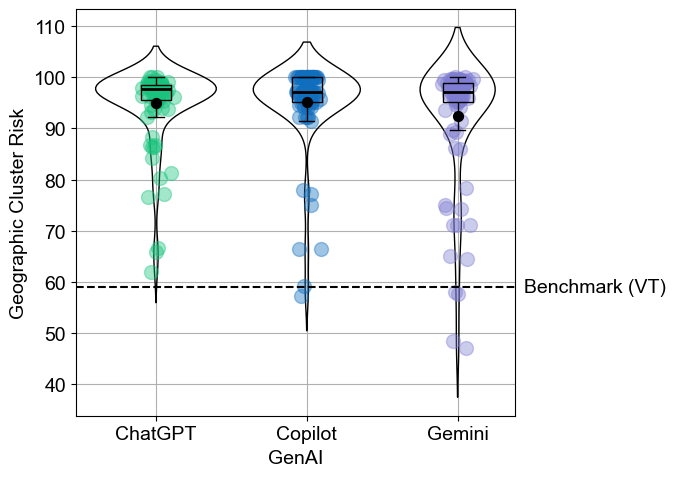

In [16]:
show_benchmark_violinplot(
    geo_us, 
    geo_benchmark_us, 
    'Benchmark (VT)', 
    'weight',
    'Geographic Cluster Risk',
    'ai',
    'study1_geoRisk.png'
)

In [17]:
# Control for different sample sizes due to exclusion criteria
geo_risk_chatgpt = geo_us[geo_us['ai'] == 'ChatGPT']['weight']
geo_risk_copilot = geo_us[geo_us['ai'] == 'Copilot']['weight']
geo_risk_gemini = geo_us[geo_us['ai'] == 'Gemini']['weight']

# Mann-Whitney U test
stat, p = stats.mannwhitneyu(geo_risk_chatgpt, geo_risk_copilot)
print(f'ChatGPT-Copilot: {stat}, {p}')
stat, p = stats.mannwhitneyu(geo_risk_copilot, geo_risk_gemini)
print(f'Copilot-Gemini: {stat}, {p}')
stat, p = stats.mannwhitneyu(geo_risk_chatgpt, geo_risk_gemini)
print(f'ChatGPT-Gemini: {stat}, {p}')

# One-sample Wilcoxon signed-rank test
stat_bench, p_bench = stats.wilcoxon(geo_risk_chatgpt - geo_benchmark_us)
print(f'ChatGPT-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(geo_risk_copilot - geo_benchmark_us)
print(f'Copilot-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(geo_risk_gemini - geo_benchmark_us)
print(f'Gemini-benchmark: {stat_bench}, {p_bench}')

# Perform Chi-Square test
count_chatgpt = [90-geo_risk_chatgpt.size, geo_risk_chatgpt.size]
count_copilot = [90-geo_risk_copilot.size, geo_risk_copilot.size]
count_gemini = [90-geo_risk_gemini.size, geo_risk_gemini.size]

chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_copilot])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_copilot, count_gemini])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_gemini]) # expected error since same number of successes
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')


ChatGPT-Copilot: 3845.0, 0.6447006893884684
Copilot-Gemini: 4538.0, 0.12366724652775629
ChatGPT-Gemini: 4132.5, 0.8145160106757225
ChatGPT-benchmark: 0.0, 1.7434256182430417e-16
Copilot-benchmark: 2.0, 2.1555800903722927e-16
Gemini-benchmark: 14.0, 2.779902389303625e-16
chi-square: 0.0, 1.0, df:1
chi-square: 0.0, 1.0, df:1


ValueError: The internally computed table of expected frequencies has a zero element at (0, 0).

                sum_sq     df         F    PR(>F)
label       383.522687    2.0  2.134402  0.120337
Residual  23898.270432  266.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ChatGPT Copilot   0.2527 0.9826 -3.0869 3.5923  False
ChatGPT  Gemini  -2.3955 0.2088 -5.7258 0.9348  False
Copilot  Gemini  -2.6482 0.1498 -5.9878 0.6914  False
-----------------------------------------------------
group: ('ChatGPT',) got t: 45.71030503913536 p_value: 0.0 dfs: 89 benchmark: 58.9625
group: ('Copilot',) got t: 40.51385783764335 p_value: 0.0 dfs: 88 benchmark: 58.9625
group: ('Gemini',) got t: 26.61767582708581 p_value: 0.0 dfs: 89 benchmark: 58.9625


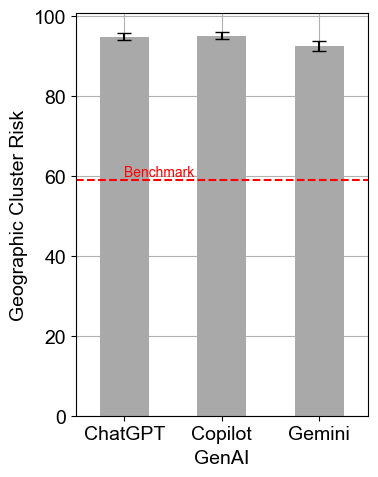

In [18]:
show_benchmark_errplot(geo_us, 
    geo_benchmark_us, 
    'Benchmark', 
    'weight',
    'Geographic Cluster Risk',
    'ai')

## Sector cluster risk

In [19]:
# Selects only investment assets and removes rows with unknown sector form the data
def prepare_sector_data(df, is_benchmark = False):
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['sector'] != 'UNKNOWN'] 
    print(df.shape)
    return df

# Calculates the sector concentration
def calculate_concentration(result, group):
    result['weight_squared'] = result['weight'] ** 2
    result_sum = result.groupby(group)['weight'].sum().reset_index()
    result_sum = result_sum['weight'] ** 2
    result_grouped = result.groupby(group)['weight_squared'].sum().reset_index()
    result_grouped['concentration'] = result_grouped['weight_squared'] / result_sum
    return result_grouped

benchmark_filtered = prepare_sector_data(vt_dummy, True)
sec_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_benchmark = calculate_concentration(sec_benchmark, group_cols)
sec_benchmark = sec_benchmark.iloc[0]['concentration']

filtered_df = prepare_sector_data(ageRisk_resolved)
sec = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
#sec = prepare_dataframe(sec, 'weight', 'sector', sec['sector'].unique()) #left out as before due to lack of classification
sec = calculate_concentration(sec, group_cols)

(9621, 15)
(1829513, 34)


            sum_sq     df        F    PR(>F)
label     0.210947    2.0  3.97878  0.019833
Residual  7.051387  266.0      NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ChatGPT Copilot   0.0664 0.0185  0.0091 0.1238   True
ChatGPT  Gemini    0.018 0.7389 -0.0392 0.0752  False
Copilot  Gemini  -0.0484 0.1168 -0.1058 0.0089  False
-----------------------------------------------------
group: ('ChatGPT',) got t: 12.297183762973043 p_value: 0.0 dfs: 89 benchmark: 0.1528
group: ('Copilot',) got t: 8.936316916571641 p_value: 0.0 dfs: 88 benchmark: 0.1528
group: ('Gemini',) got t: 11.138803474821055 p_value: 0.0 dfs: 89 benchmark: 0.1528
means:
ai
ChatGPT    0.2957
Copilot    0.3621
Gemini     0.3137
Name: concentration, dtype: float64
stds:
ai
ChatGPT    0.1103
Copilot    0.2210
Gemini     0.1371
Name: concentration, dtype: float64
ai
ChatGPT    90
Copilot    89
Gemi

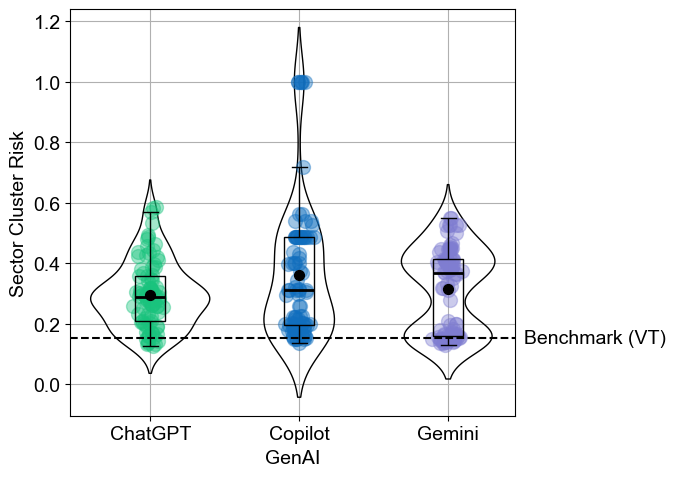

In [20]:
show_benchmark_violinplot(
    sec, 
    sec_benchmark, 
    'Benchmark (VT)', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'ai',
    'study1_sectorRisk'
)

In [21]:
# Control for different sample sizes due to exclusion criteria
sec_risk_chatgpt = sec[sec['ai'] == 'ChatGPT']['concentration']
sec_risk_copilot = sec[sec['ai'] == 'Copilot']['concentration']
sec_risk_gemini = sec[sec['ai'] == 'Gemini']['concentration']

# Mann-Whitney U test
stat, p = stats.mannwhitneyu(sec_risk_chatgpt, sec_risk_copilot)
print(f'ChatGPT-Copilot: {stat}, {p}')
stat, p = stats.mannwhitneyu(sec_risk_copilot, sec_risk_gemini)
print(f'Copilot-Gemini: {stat}, {p}')
stat, p = stats.mannwhitneyu(sec_risk_chatgpt, sec_risk_gemini)
print(f'ChatGPT-Gemini: {stat}, {p}')

# One-sample Wilcoxon signed-rank test
stat_bench, p_bench = stats.wilcoxon(sec_risk_chatgpt - sec_benchmark)
print(f'ChatGPT-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(sec_risk_copilot - sec_benchmark)
print(f'Copilot-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(sec_risk_gemini - sec_benchmark)
print(f'Gemini-benchmark: {stat_bench}, {p_bench}')

# Perform Chi-Square test
count_chatgpt = [90-sec_risk_chatgpt.size, sec_risk_chatgpt.size]
count_copilot = [90-sec_risk_copilot.size, sec_risk_copilot.size]
count_gemini = [90-sec_risk_gemini.size, sec_risk_gemini.size]

chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_copilot])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_copilot, count_gemini])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_gemini]) # expected error since same number of successes
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')


ChatGPT-Copilot: 3556.5, 0.1960509890621559
Copilot-Gemini: 4523.0, 0.13531203794281335
ChatGPT-Gemini: 3730.0, 0.36067165400052215
ChatGPT-benchmark: 67.0, 1.6006223685231194e-15
Copilot-benchmark: 31.0, 6.952639587293615e-16
Gemini-benchmark: 262.0, 6.743928398194115e-13
chi-square: 0.0, 1.0, df:1
chi-square: 0.0, 1.0, df:1


ValueError: The internally computed table of expected frequencies has a zero element at (0, 0).

            sum_sq     df        F    PR(>F)
label     0.210947    2.0  3.97878  0.019833
Residual  7.051387  266.0      NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ChatGPT Copilot   0.0664 0.0185  0.0091 0.1238   True
ChatGPT  Gemini    0.018 0.7389 -0.0392 0.0752  False
Copilot  Gemini  -0.0484 0.1168 -0.1058 0.0089  False
-----------------------------------------------------
group: ('ChatGPT',) got t: 12.297183762973043 p_value: 0.0 dfs: 89 benchmark: 0.1528
group: ('Copilot',) got t: 8.936316916571641 p_value: 0.0 dfs: 88 benchmark: 0.1528
group: ('Gemini',) got t: 11.138803474821055 p_value: 0.0 dfs: 89 benchmark: 0.1528


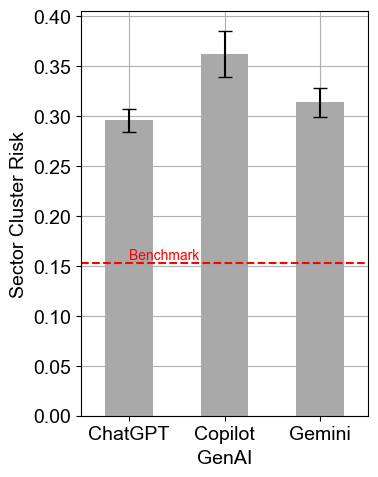

In [23]:
show_benchmark_errplot(
    sec, 
    sec_benchmark, 
    'Benchmark', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'ai')

## Concentration Map

In [24]:
# Selects only investment assets and assets with known country and sector
def prepare_overview_data(df, isBenchmark = False):
    filtered_df = df.copy()
    if not isBenchmark:
        filtered_df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    filtered_df = filtered_df[filtered_df['country'] != 'UNKNOWN'] 
    filtered_df = filtered_df[filtered_df['sector'] != 'UNKNOWN']
    filtered_df['country'] = filtered_df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(filtered_df.shape)
    return filtered_df

# Calculates the means, stds, and sample sizes
def calc_overview(raw, column, column_label, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

# Calculates the t-test between a sample and a fixed value across groups
def show_matched_ttest(raw, column, benchmark):
    for group_name, group_data in raw.groupby(column):
        group_values = group_data['weight']
        benchmark_val = 0
        if len(benchmark[benchmark[column] == group_name]) > 0:
            benchmark_val = benchmark[benchmark[column] == group_name].iloc[0]['weight']
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark_val)
        print(f'group: {group_name} with mean {round(group_values.mean(),4)} and std {round(group_values.std(),4)} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark_val, 4)}')

filtered_df = prepare_overview_data(ageRisk_resolved)

sec_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_ov = fill_options(filtered_df, sec_ov, 'sector', group_cols)
calc_overview(sec_ov, 'weight','weight','sector')

bench_sec_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
show_matched_ttest(sec_ov, 'sector', bench_sec_ov)

geo_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
gec_ov = fill_options(filtered_df, geo_ov, 'country', group_cols)
calc_overview(geo_ov, 'weight','weight','country')

bench_geo_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
show_matched_ttest(geo_ov, 'country', bench_geo_ov)


(1805303, 34)
             sum_sq      df           F  PR(>F)
label     34.093617    13.0  290.470352     0.0
Residual  33.875892  3752.0         NaN     NaN
                                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                                     
                  group1                                     group2                   meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------
           Academic & Educational Services                            Basic Materials   0.0114 0.9832 -0.0161  0.0389  False
           Academic & Educational Services                     Communication Services   0.0087 0.9987 -0.0188  0.0362  False
           Academic & Educational Services                          Consumer Cyclical   0.2095    0.0   0.182   0.237   True
           Academic & Educational Services                     Consumer Non-Cyclicals   0.04

(9485, 15)


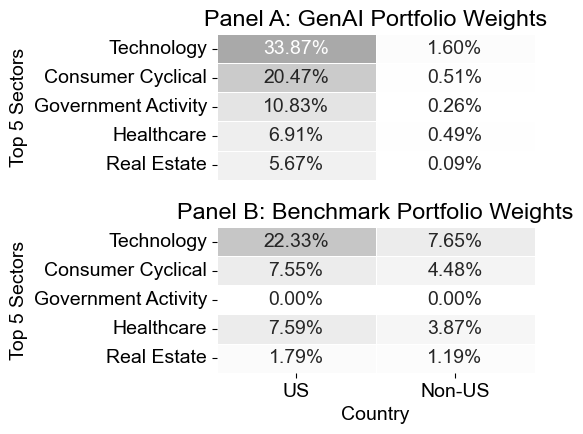

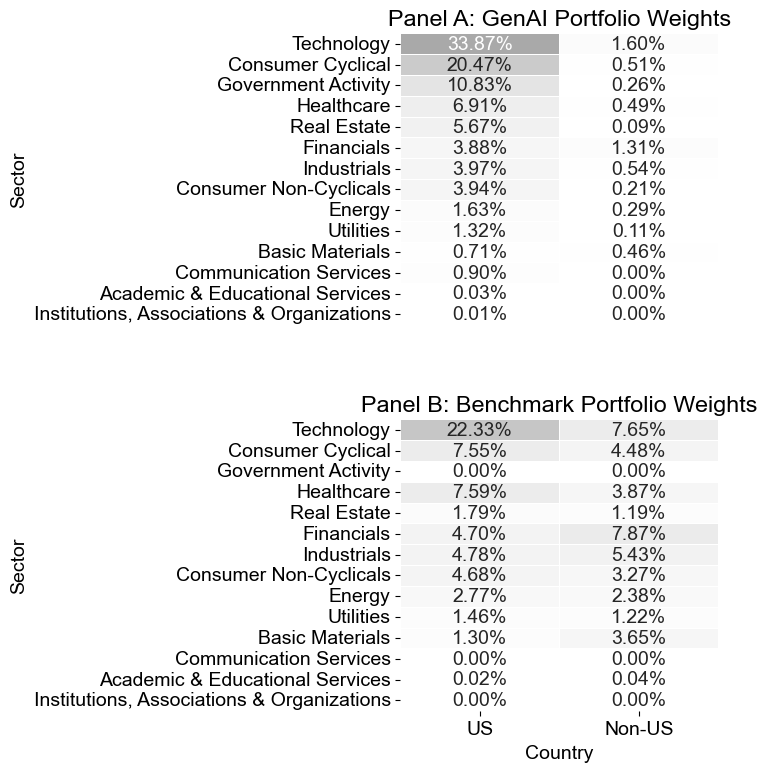

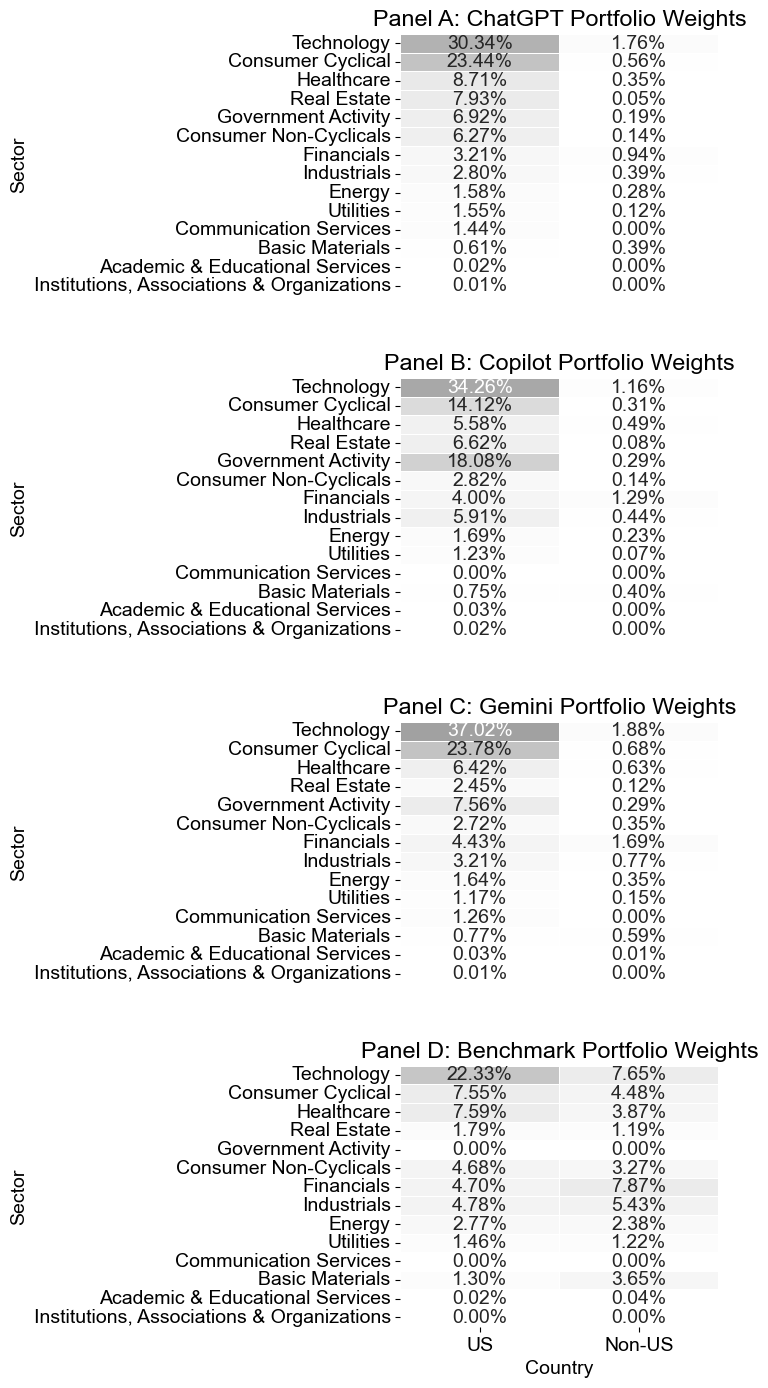

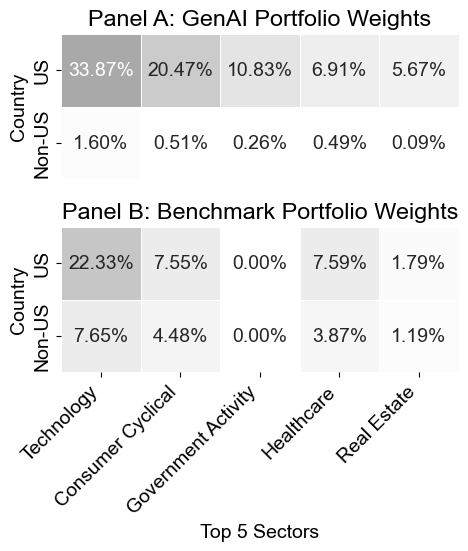

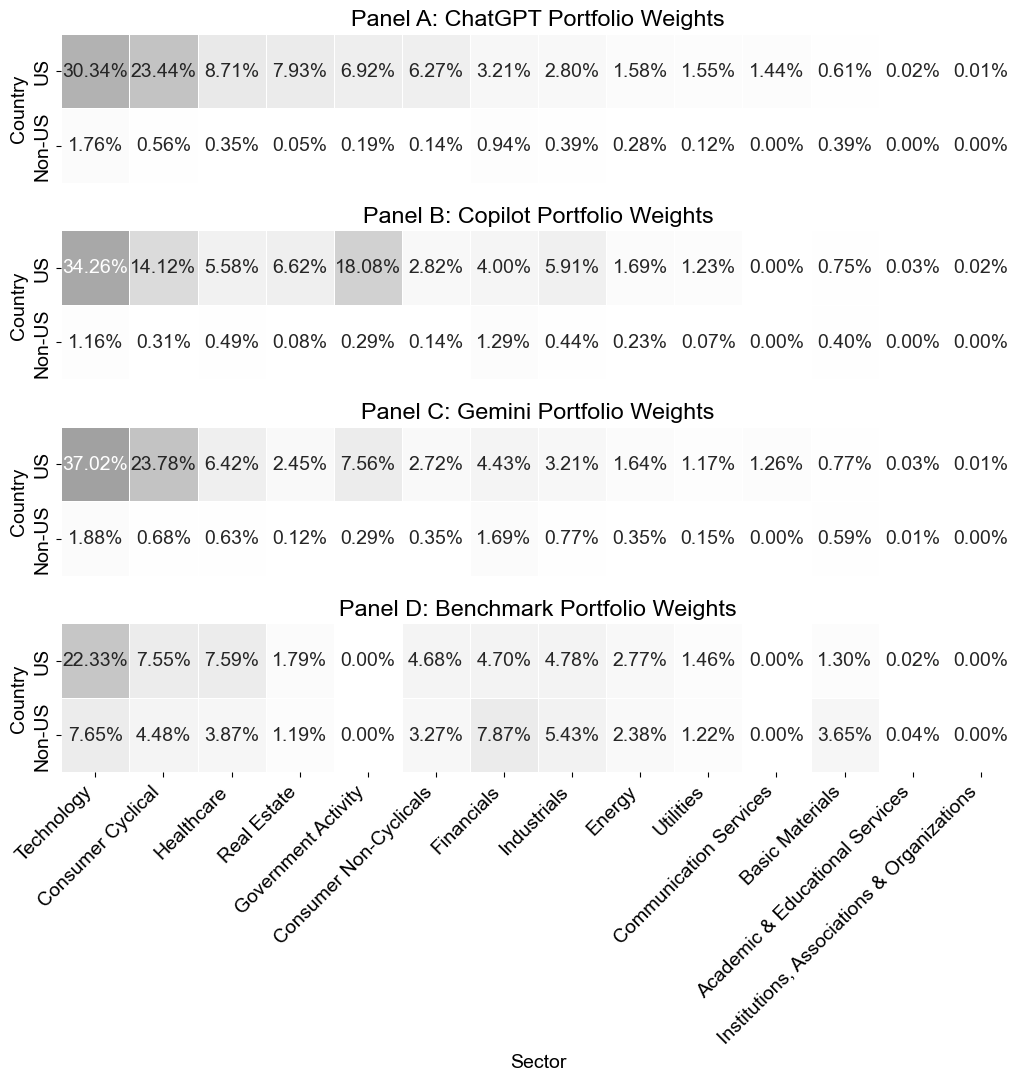

In [25]:
# Creates a data frame which contains all combinations of countries and sectors within each portfolio
def fill_concentration(filtered_df, res, group_cols):
    sectors = filtered_df['sector'].unique()
    countries = filtered_df['country'].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame(
        [row + [sector, country] for row in group_cols_df.values.tolist() for sector, country in itertools.product(sectors, countries)], 
        columns=group_cols+['sector', 'country'])

    merged_df = pd.merge(all_combinations, res, on=group_cols+['sector', 'country'], how='left')
    merged_df.fillna(0, inplace=True)
    return merged_df

# Prints a Seaborn heatmap
def custom_heatmap(data, color_map="gray_r", annot=True, fmt=".2%", ax=None, max_color=None, **kwargs):
    sns.heatmap(data, cmap=color_map, annot=annot, fmt=fmt, linewidths=.5, cbar=False, ax=ax, vmax=max_color, **kwargs)

# Prints a sector, country concentration map in horizontal orientation
def show_faceted_heatmap_horizontal(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).nlargest(5).index
    else:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(columns=column_order, fill_value=0)
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)        
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    x_label = 'Top 5 Sectors' if show_top else 'Sector'
    g.set_axis_labels(x_label, "Country")
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

# Prints a sector, country concentration map in vertical orientation
def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).nlargest(5).index
    else:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(index=row_order, fill_value=0)
        facet_pivot = facet_pivot.reindex(columns=facet_pivot.columns[::-1], fill_value=0)  # Reverse column order
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)        
        ax.set_yticks(np.arange(len(facet_pivot.index)) + 0.5)
        ax.set_yticklabels(facet_pivot.index, va='center')  # Set y-tick labels
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    y_label = 'Top 5 Sectors' if show_top else 'Sector'
    g.set_axis_labels("Country", y_label)
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'GenAI'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['ai'] 

combined = pd.concat([concentration_overview, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined, 'study1_overview_concentration_map', True, 4, 4)
show_faceted_heatmap(combined, 'study1_concentration_map', False, 4, 8)

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study1_concentration_map_details', False, 4, 14)
show_faceted_heatmap_horizontal(combined, 'study1_concentration_map_overview_horizontal', True, 5, 4)
show_faceted_heatmap_horizontal(combined_details, 'study1_concentration_map_details_horizontal', False, 12, 8 )

## Active investment allocation risk

In [26]:
ter_data_study1 = pd.read_csv('../study1/etf_holdings/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study1 = ter_data_study1.iloc[1:].reset_index()
ter_data_study1.columns = ['fund', 'fund_type', 'ter', 'management_approach']
ter_data_study1 = ter_data_study1[~ter_data_study1['management_approach'].isna()]
ter_data_study3 = pd.read_csv('../study2b/data/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study3 = ter_data_study3.iloc[1:].reset_index()
ter_data_study3.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data = pd.concat([ter_data_study1, ter_data_study3], ignore_index=True)
ter_data['fund'] = ter_data['fund'].str.split('.').str[0]
condition = ter_data['ter'].str.startswith('Unable to')
ter_data.loc[condition & ~ter_data['ter'].isna(), 'ter'] = np.nan

In [27]:
# Sets the management approach depending on the asset type
def set_management_approach(row):
    if row['asset_type'] in ['EQUITY', 
                               'CRYPTOCURRENCY', 
                               'BOND', 
                               'MONEYMARKET', 
                               'SEEDINVEST', 
                               'REALESTATE', 
                               'ROBO', 
                               'VENTURECAPITAL',
                               'PRIVATEEQUITY']:
        return 'Active'
    else:
        ticker = row['ticker_symbol']
        if ticker in ter_data['fund'].unique():
            approach = ter_data[ter_data['fund'] == ticker].iloc[0]['management_approach']
            return approach
        else:
            return 'UNKNOWN'

# Calculates the management approach share within each portfolio
def calculate_approach_weight(group):
    summed = group.groupby('management_approach')['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['management_weight'] = summed['amount_to_invest'] / total_amount
    return summed

# Selects only assets where the management approach is known and calculates the management approach share per portfolio
def get_management_data(df, groups):
    df = df[df['management_approach'] != 'UNKNOWN']
    management_data = df.groupby(groups).apply(calculate_approach_weight).reset_index()
    return management_data      

investment_ageRisk = ageRisk[~ageRisk['asset_type'].isin(['SAVING', 'DEPOSIT', 'IRA', 'ANNUITY'])]
investment_ageRisk = investment_ageRisk.copy()
investment_ageRisk['management_approach'] = investment_ageRisk.apply(set_management_approach, axis=1)
management_data = get_management_data(investment_ageRisk, group_cols)
management_data = prepare_dataframe(management_data, 'management_weight', 'management_approach', ['Active', 'Passive']) # required to include rows where everything is passive
management_data = management_data[management_data['management_approach'] == 'Active']
management_data['management_weight'] = management_data['management_weight'] *100


                 sum_sq     df         F    PR(>F)
label       1875.793533    2.0  0.796961  0.451766
Residual  314216.518486  267.0       NaN       NaN
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
ChatGPT Copilot  -5.5659 0.5221 -17.6186  6.4869  False
ChatGPT  Gemini   0.0506 0.9999 -12.0021 12.1034  False
Copilot  Gemini   5.6165  0.516  -6.4363 17.6693  False
-------------------------------------------------------
group: ('ChatGPT',) got t: 18.64628152870567 p_value: 0.0 dfs: 89 benchmark: 0
group: ('Copilot',) got t: 13.432427850165451 p_value: 0.0 dfs: 89 benchmark: 0
group: ('Gemini',) got t: 14.913660670788543 p_value: 0.0 dfs: 89 benchmark: 0
means:
ai
ChatGPT    57.4149
Copilot    51.8490
Gemini     57.4655
Name: management_weight, dtype: float64
stds:
ai
ChatGPT    29.2115
Copilot    36.6191
Gemini     36.5548
Name: management_weight, dtype: float64
ai
C

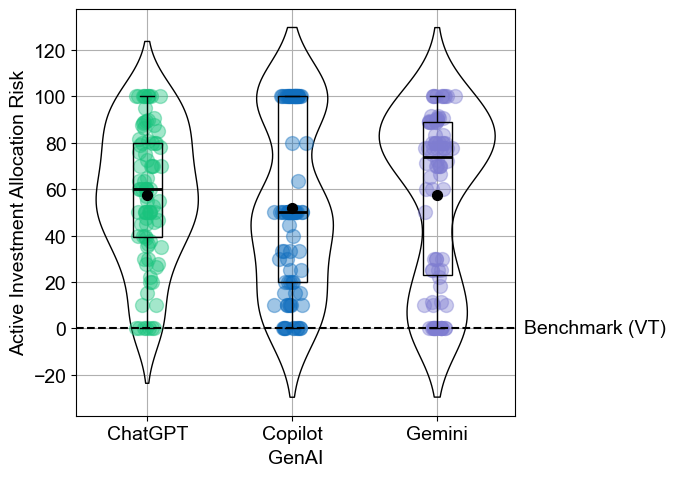

In [28]:
show_benchmark_violinplot(
    management_data, 
    0, 
    'Benchmark (VT)', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'ai',
    'study1_activeRisk'
)

                 sum_sq     df         F    PR(>F)
label       1875.793533    2.0  0.796961  0.451766
Residual  314216.518486  267.0       NaN       NaN
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
ChatGPT Copilot  -5.5659 0.5221 -17.6186  6.4869  False
ChatGPT  Gemini   0.0506 0.9999 -12.0021 12.1034  False
Copilot  Gemini   5.6165  0.516  -6.4363 17.6693  False
-------------------------------------------------------
group: ('ChatGPT',) got t: 18.64628152870567 p_value: 0.0 dfs: 89 benchmark: 0
group: ('Copilot',) got t: 13.432427850165451 p_value: 0.0 dfs: 89 benchmark: 0
group: ('Gemini',) got t: 14.913660670788543 p_value: 0.0 dfs: 89 benchmark: 0


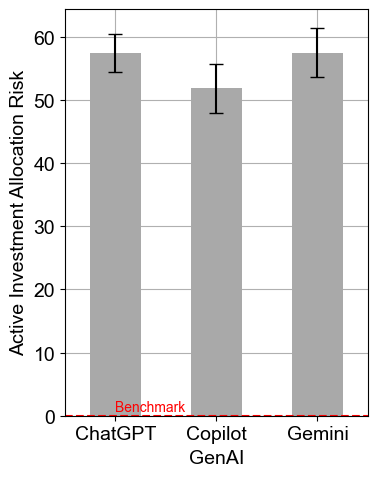

In [29]:
show_benchmark_errplot(
    management_data, 
    0, 
    'Benchmark', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'ai')

## Total Expense Risk

In [30]:
fund_identifiers = ter_data['fund'].unique()

# Assigns the TER of an asset depending on the ticker symbol
def assign_ter(row):
    ticker = row['ticker_symbol']
    if ticker in fund_identifiers:
        return ter_data[ter_data['fund'] == ticker].iloc[0]['ter']
    else: 
        return np.nan

# Calculates the weight of an asset within a portfolio
def calculate_fund_weight(group, elem):
    summed = group.groupby(elem)['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['weight'] = summed['amount_to_invest'] / total_amount
    return summed

ter_benchmark = float(ter_data[ter_data['fund'] == 'VT'].iloc[0]['ter'])
ter_benchmark = ter_benchmark

filtered_df = ageRisk[ageRisk['asset_type'].isin(['ETF', 'MUTUALFUND'])]
#filtered_df = ageRisk.copy()
ter_df = filtered_df.copy()
ter_df = ter_df.groupby(group_cols).apply(calculate_fund_weight, elem='ticker_symbol').reset_index()
ter_df['ter'] = ter_df.apply(assign_ter, axis=1)
ter_df['ter'] = ter_df['ter'].astype(float)
#ter_df['ter'].fillna(0, inplace=True)
ter_df['ter_weight'] = ter_df['ter'] * ter_df['weight']
grouped_ter = ter_df.groupby(group_cols)['ter_weight'].sum().reset_index()

             sum_sq     df         F    PR(>F)
label      0.224050    2.0  2.533437  0.081516
Residual  10.568241  239.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ChatGPT Copilot  -0.0748 0.0748 -0.1552 0.0057  False
ChatGPT  Gemini  -0.0475 0.2971 -0.1227 0.0277  False
Copilot  Gemini   0.0272 0.7023 -0.0529 0.1073  False
-----------------------------------------------------
group: ('ChatGPT',) got t: 5.762617269913809 p_value: 0.0 dfs: 85 benchmark: 0.07
group: ('Copilot',) got t: 2.6344449831822425 p_value: 0.0105 dfs: 67 benchmark: 0.07
group: ('Gemini',) got t: 3.385803382909523 p_value: 0.0011 dfs: 87 benchmark: 0.07
means:
ai
ChatGPT    0.2013
Copilot    0.1265
Gemini     0.1537
Name: ter_weight, dtype: float64
stds:
ai
ChatGPT    0.2112
Copilot    0.1768
Gemini     0.2319
Name: ter_weight, dtype: float64
ai
ChatGPT    86
Copilot    68
Gemin

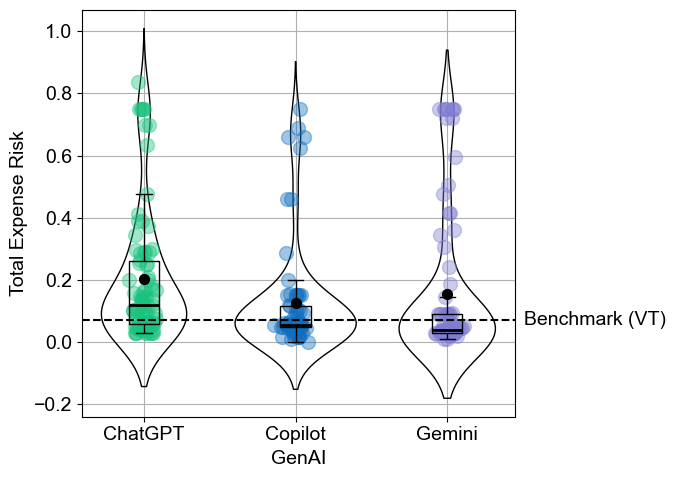

In [31]:
show_benchmark_violinplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark (VT)', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'ai',
    'study1_terRisk'
)

In [32]:
# Control for different sample sizes due to exclusion criteria
ter_risk_chatgpt = grouped_ter[grouped_ter['ai'] == 'ChatGPT']['ter_weight']
ter_risk_copilot = grouped_ter[grouped_ter['ai'] == 'Copilot']['ter_weight']
ter_risk_gemini = grouped_ter[grouped_ter['ai'] == 'Gemini']['ter_weight']

# Mann-Whitney U test
stat, p = stats.mannwhitneyu(ter_risk_chatgpt, ter_risk_copilot)
print(f'ChatGPT-Copilot: {stat}, {p}')
stat, p = stats.mannwhitneyu(ter_risk_copilot, ter_risk_gemini)
print(f'Copilot-Gemini: {stat}, {p}')
stat, p = stats.mannwhitneyu(ter_risk_chatgpt, ter_risk_gemini)
print(f'ChatGPT-Gemini: {stat}, {p}')

# One-sample Wilcoxon signed-rank test
stat_bench, p_bench = stats.wilcoxon(ter_risk_chatgpt - ter_benchmark)
print(f'ChatGPT-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(ter_risk_copilot - ter_benchmark)
print(f'Copilot-benchmark: {stat_bench}, {p_bench}')
stat_bench, p_bench = stats.wilcoxon(ter_risk_gemini - ter_benchmark)
print(f'Gemini-benchmark: {stat_bench}, {p_bench}')

# Perform Chi-Square test
count_chatgpt = [90-ter_risk_chatgpt.size, ter_risk_chatgpt.size]
count_copilot = [90-ter_risk_copilot.size, ter_risk_copilot.size]
count_gemini = [90-ter_risk_gemini.size, ter_risk_gemini.size]

chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_copilot])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_copilot, count_gemini])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')
chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_chatgpt, count_gemini]) # expected error since same number of successes
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')

ChatGPT-Copilot: 3915.5, 0.00031025056574846325
Copilot-Gemini: 3576.0, 0.03679737494800362
ChatGPT-Gemini: 5369.5, 1.778177353686139e-06
ChatGPT-benchmark: 616.0, 6.569118880960886e-08
Copilot-benchmark: 1112.5, 0.7115471005898444
Gemini-benchmark: 1654.0, 0.20494837363318263
chi-square: 12.992007992007991, 0.00031282331651586733, df:1
chi-square: 17.35576923076923, 3.099559223717972e-05, df:1
chi-square: 0.17241379310344826, 0.6779754429107876, df:1


             sum_sq     df         F    PR(>F)
label      0.224050    2.0  2.533437  0.081516
Residual  10.568241  239.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ChatGPT Copilot  -0.0748 0.0748 -0.1552 0.0057  False
ChatGPT  Gemini  -0.0475 0.2971 -0.1227 0.0277  False
Copilot  Gemini   0.0272 0.7023 -0.0529 0.1073  False
-----------------------------------------------------
group: ('ChatGPT',) got t: 5.762617269913809 p_value: 0.0 dfs: 85 benchmark: 0.07
group: ('Copilot',) got t: 2.6344449831822425 p_value: 0.0105 dfs: 67 benchmark: 0.07
group: ('Gemini',) got t: 3.385803382909523 p_value: 0.0011 dfs: 87 benchmark: 0.07


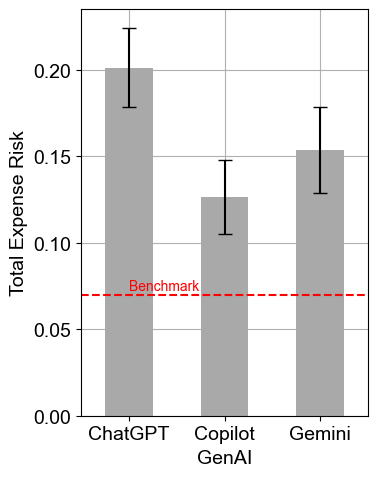

In [33]:
show_benchmark_errplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'ai')

## Trend chasing risk

In [34]:
vt_prepared = benchmark_vt
vt_prepared['symbol'] = vt_prepared['symbol'].str.split('.').str[0]
vt_equities = vt_prepared['symbol'].unique()

volume_dict = {}
start_date = "2023-04-01"
end_date = "2023-06-30"

In [ ]:
for symbol in vt_equities:
    stock_data = yf.download(f'{symbol}', start=start_date, end=end_date, interval = '3mo')
    total_volume = stock_data['Volume'].sum()
    volume_dict[symbol] = total_volume

In [ ]:
for key, value in volume_dict.items():
    if isinstance(value, np.int64):
        volume_dict[key] = int(value)
with open('../study1/benchmark/vt_benchmark_holdings_volume_202304_3m.json', 'w') as json_file:
    json.dump(volume_dict, json_file)

In [35]:
json_file_path = '../study1/benchmark/vt_benchmark_holdings_volume_202304_3m.json'
with open(json_file_path, 'r') as json_file:
    volume_dict = json.load(json_file)
    
most_active_stocks = sorted(volume_dict.items(), key=lambda x: x[1], reverse=True)

# Most traded in the last 3 months by volume
for i, (symbol, volume) in enumerate(most_active_stocks[:20], 1):
    print(f"{i}. Symbol: {symbol}, Total Volume: {volume}")

1. Symbol: TSLA, Total Volume: 8627649000
2. Symbol: PLTR, Total Volume: 4490639300
3. Symbol: AMD, Total Volume: 4201460900
4. Symbol: AMZN, Total Volume: 3899624000
5. Symbol: F, Total Volume: 3708650700
6. Symbol: AAPL, Total Volume: 3541966300
7. Symbol: NIO, Total Volume: 3235177200
8. Symbol: SOFI, Total Volume: 3204363300
9. Symbol: BAC, Total Volume: 3044131000
10. Symbol: NKLA, Total Volume: 3010655200
11. Symbol: NVDA, Total Volume: 2965437300
12. Symbol: INTC, Total Volume: 2762170900
13. Symbol: CCL, Total Volume: 2498772900
14. Symbol: T, Total Volume: 2442695800
15. Symbol: GOOGL, Total Volume: 2081408400
16. Symbol: LCID, Total Volume: 1905241200
17. Symbol: AI, Total Volume: 1890107300
18. Symbol: NU, Total Volume: 1711794600
19. Symbol: MSFT, Total Volume: 1699893000
20. Symbol: PACW, Total Volume: 1662858500


In [36]:
# Determines the assets with the highest money allocation in GenAI advice
def getTop(conds, cond, equities_cond, equities_grouped):
    top_data = {}
    
    for co in conds:
        top_equities_total = equities_cond[equities_cond['ai'] == co]['amount_to_invest']
        top_total = cond[cond['ai'] == co]['amount_to_invest']
        top_cond = equities_grouped[equities_grouped['ai'] == co]
        top_cond = top_cond.copy()
        top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
        top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
        top_cond = top_cond.sort_values(by='amount_to_invest', ascending=False)
        top_data[co] = top_cond
        
    return top_data

# Prints the top asset data
def showTop(conds, top_data):
    top_dict = {}
    for co in conds:
        top = top_data[co]
        top_equities_sum = top['pct_of_equities'].sum()
        top_total_sum = top['pct_of_total'].sum()
        print(f'{co} top: % of equities: {top_equities_sum} and % of total {top_total_sum}')

        top3 = top.head(3)
        top3_equities_sum = top3['pct_of_equities'].sum()
        top3_total_sum = top3['pct_of_total'].sum()
        print(f'{co} top 3: % of equities: {top3_equities_sum} and % of total {top3_total_sum}')
        print(f'{top3}\n')
        top_dict[co] = top3['ticker_symbol'].tolist()
    return top_dict
    

ais = ['Gemini', 'Copilot', 'ChatGPT']
ageRisk_cond = ageRisk.groupby(['ai'])['amount_to_invest'].sum().reset_index()
ageRisk_equities = ageRisk[ageRisk['asset_type'] == 'EQUITY']
ageRisk_equities_cond = ageRisk_equities.groupby(['ai'])['amount_to_invest'].sum().reset_index()
ageRisk_equities_grouped = ageRisk_equities.groupby(['ai','ticker_symbol'])['amount_to_invest'].sum().reset_index()

top_data = getTop(ais, ageRisk_cond, ageRisk_equities_cond, ageRisk_equities_grouped)
top_dict = showTop(ais, top_data)

Gemini top: % of equities: 1.0 and % of total 0.3803680981595092
Gemini top 3: % of equities: 0.7272727272727273 and % of total 0.2766313441160067
        ai ticker_symbol  amount_to_invest  pct_of_equities  pct_of_total
42  Gemini          AAPL            107500         0.315249      0.119911
43  Gemini          AMZN             77000         0.225806      0.085890
50  Gemini          MSFT             63500         0.186217      0.070831

Copilot top: % of equities: 0.9999999999999999 and % of total 0.31067961165048535
Copilot top 3: % of equities: 0.5528169014084507 and % of total 0.17174894024340215
         ai ticker_symbol  amount_to_invest  pct_of_equities  pct_of_total
41  Copilot          TSLA             68000         0.239437      0.074388
38  Copilot          NVDA             48000         0.169014      0.052509
28  Copilot          AAPL             41000         0.144366      0.044852

ChatGPT top: % of equities: 0.9999999999999999 and % of total 0.3935037273695421
ChatGPT 

In [37]:
top3_benchmark = vt_dummy.sort_values(by='weight', ascending=False).head(3) 
top3_benchmark #all included in top 20 most traded

,fund,code,equity,symbol,#shares,weight,country,type,sector,amount,cond,ai,age,risk-taking,iteration
93854,VT,LP40120747,APPLE INC ORD,AAPL,8132495.0,0.038911,UNITED STATES,Ordinary Shares,Technology,389.11,VT,VT,1,low,0
93855,VT,NaN,MICROSOFT CORP ORD,MSFT,4055679.0,0.033854,UNITED STATES,Ordinary Shares,Technology,338.54,VT,VT,1,low,0
93856,VT,NaN,AMAZON.COM INC ORD,AMZN,4909845.0,0.017257,UNITED STATES,Ordinary Shares,Consumer Cyclical,172.57,VT,VT,1,low,0


In [38]:
# Calculates the share of the top 3 assets by volume in GenAI advice
def calcTopMeans(df, top_dict):
    top_df = None

    for ai, top_assets in top_dict.items():
        filtered_df = df[(df['ai'] == ai) & (df['ticker_symbol'].isin(top_assets))]
        top_df = pd.concat([top_df, filtered_df])
    
    top_df = prepare_dataframe(top_df, 'weight')    
    result = top_df.groupby(['ai', 'age', 'risk-taking', 'iteration'])['weight'].sum().reset_index()
    return result
 
benchmark_trends = top3_benchmark.groupby('ai')['weight'].sum().reset_index().iloc[0]['weight']
trends_data = calcTopMeans(ageRisk_resolved, top_dict)

trends_data['weight'] = trends_data['weight'] *100
benchmark_trends = benchmark_trends * 100

                 sum_sq     df         F    PR(>F)
label       5054.294934    2.0  4.258879  0.015111
Residual  158433.320537  267.0       NaN       NaN
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
ChatGPT Copilot  -7.3077 0.1112 -15.8661  1.2508  False
ChatGPT  Gemini   2.9935 0.6882   -5.565 11.5519  False
Copilot  Gemini  10.3011 0.0136   1.7427 18.8596   True
-------------------------------------------------------
group: ('ChatGPT',) got t: 7.327245144775681 p_value: 0.0 dfs: 89 benchmark: 9.0022
group: ('Copilot',) got t: 4.593278282910209 p_value: 0.0 dfs: 89 benchmark: 9.0022
group: ('Gemini',) got t: 5.566624342561475 p_value: 0.0 dfs: 89 benchmark: 9.0022
means:
ai
ChatGPT    24.9219
Copilot    17.6142
Gemini     27.9153
Name: weight, dtype: float64
stds:
ai
ChatGPT    20.6117
Copilot    17.7870
Gemini     32.2324
Name: weight, dtype: float64
ai
ChatGPT   

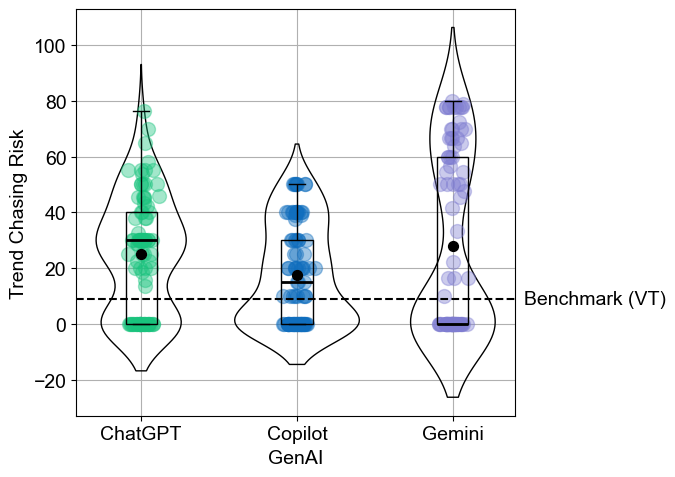

In [39]:
show_benchmark_violinplot(
    trends_data, 
    benchmark_trends, 
    'Benchmark (VT)', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'ai',
    'study1_trendRisk'
)

                 sum_sq     df         F    PR(>F)
label       5054.294934    2.0  4.258879  0.015111
Residual  158433.320537  267.0       NaN       NaN
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
ChatGPT Copilot  -7.3077 0.1112 -15.8661  1.2508  False
ChatGPT  Gemini   2.9935 0.6882   -5.565 11.5519  False
Copilot  Gemini  10.3011 0.0136   1.7427 18.8596   True
-------------------------------------------------------
group: ('ChatGPT',) got t: 7.327245144775681 p_value: 0.0 dfs: 89 benchmark: 9.0022
group: ('Copilot',) got t: 4.593278282910209 p_value: 0.0 dfs: 89 benchmark: 9.0022
group: ('Gemini',) got t: 5.566624342561475 p_value: 0.0 dfs: 89 benchmark: 9.0022


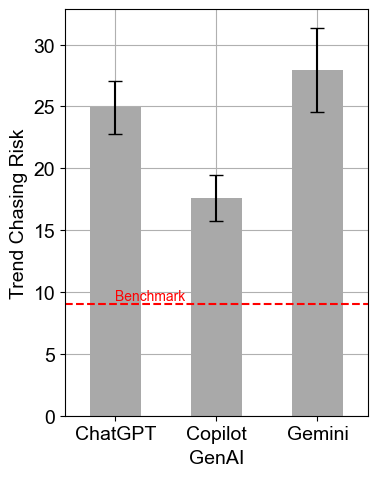

In [40]:
show_benchmark_errplot(
    trends_data, 
    benchmark_trends, 
    'Benchmark', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'ai')